# Vortex Utilization Report Bottleneck Analysis

Vivado `hier_utilization.rpt`를 파싱해 모듈별 FPGA 자원 사용량을 확인하고 bottleneck이 되는 계층을 찾습니다.

- 원본 파서: `hwexplorer.report_parser.VivadoUtilizationParser` (패턴 기반 집계용)
- 여기서는 bottleneck 탐색을 위해 **모든 인스턴스 전체**를 raw 로 읽어 DataFrame 으로 만듭니다.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hwexplorer.report_parser import VivadoParser

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

2026-04-20 18:57:54,571 - hwexplorer - INFO - register per_group_exporter


2026-04-20 18:57:54,576 - hwexplorer - INFO - register pie_breakdown_visualizer


2026-04-20 18:57:54,578 - hwexplorer - INFO - register bar_compare_visualizer


2026-04-20 18:57:54,578 - hwexplorer - INFO - register bar_breakdown_visualizer


2026-04-20 18:57:54,579 - hwexplorer - INFO - register scatter_visualizer


## 1. 분석할 report 지정

In [2]:
# 비교하고 싶은 여러 빌드를 넣을 수 있음
REPORTS = {
    'v1':           '/home/jaeyongjang/project.local/vortex/build/hw/syn/xilinx/xrt/core1_fpint_improve_xilinx_u55c_gen3x16_xdma_3_202210_1_hw/_x/link/vivado/vpl/prj/prj.runs/impl_1/hier_utilization.rpt',
    'v2_routefail': '/home/jaeyongjang/project.local/vortex/build/hw/syn/xilinx/xrt/core1_fpint_improve_v2_xilinx_u55c_gen3x16_xdma_3_202210_1_hw/_x/link/vivado/vpl/prj/prj.runs/impl_1/hier_utilization.rpt',
}
# Primary build to analyse in sections 3-11. Switch to 'v1' to analyse the earlier build.
ACTIVE_TAG = 'v2_routefail'

# FPGA 전체 가용 리소스 (xcu55c). Utilization % 와 headroom 계산에 사용.
DEVICE_BUDGET = {
    'total_luts':  1304064,
    'logic_luts':  1304064,
    'lutrams':     600960,
    'srls':        600960,
    'ffs':        2607360,
    'ramb36':        2016,
    'ramb18':        4032,
    'uram':           960,
    'dsp_blocks':    9024,
}

# --- scope knobs ---
# Limit analysis to a subtree under this path segment. Empty string = whole chip.
# Common: 'ulp' (XRT user logic partition — skips level0_i / static shell).
SCOPE_PREFIX = 'ulp'

for tag, p in REPORTS.items():
    print(f"{tag:30s} exists={os.path.exists(p)}  size={os.path.getsize(p) if os.path.exists(p) else 0:,}B")

v1                             exists=True  size=4,231,241B
v2_routefail                   exists=True  size=4,194,948B


## 2. Raw parser: 모든 인스턴스 → DataFrame

`VivadoParser.parse_pipe_table_section` 을 재사용해 `1. Utilization by Hierarchy` 섹션의 파이프 테이블을 통째로 뽑습니다.

- `depth`: 인스턴스 열의 leading space 로 계층 깊이 계산 (Vivado 2 칸 들여쓰기 가정)
- `(module)` 형식의 self-row 는 **own 리소스**를 나타내므로 별도 컬럼으로 보존

In [3]:
RESOURCE_COLS = [
    'Total LUTs', 'Logic LUTs', 'LUTRAMs', 'SRLs', 'FFs',
    'RAMB36', 'RAMB18', 'URAM', 'DSP Blocks',
]

def _extract_count(s):
    s = s.strip()
    m = re.match(r'(\d+)', s)
    return int(m.group(1)) if m else 0

def parse_hier_util(path: str) -> pd.DataFrame:
    """Return full hierarchical util as a DataFrame with columns:
        depth, instance, module, full_path, is_self, <resource cols...>
    """
    with open(path, 'r') as fd:
        lines = fd.readlines()

    section_starts = [i for i, ln in enumerate(lines)
                      if re.match(r'^1\. Utilization by Hierarchy\s*$', ln)]
    if not section_starts:
        raise ValueError(f"no 'Utilization by Hierarchy' section in {path}")
    section_start = section_starts[-1]

    parser = VivadoParser()
    headers, table_lines = parser.parse_pipe_table_section(lines, section_start)
    col_map = {h: i for i, h in enumerate(headers)}

    rows = []
    name_hierarchy = []
    for line in table_lines:
        cells = line.split('|')[1:-1]
        if len(cells) < 2:
            continue
        instance_raw = cells[0]
        instance = instance_raw.strip()
        module = cells[col_map['Module']].strip() if 'Module' in col_map else ''
        leading = len(instance_raw) - len(instance_raw.lstrip(' '))
        depth = max(0, (leading - 1) // 2)

        is_self = instance.startswith('(') and instance.endswith(')')
        clean_name = instance.strip('()') if is_self else instance

        # hierarchy 관리: self-row 는 path 에 영향 없음, 일반 row 만 push
        if not is_self:
            while len(name_hierarchy) > depth:
                name_hierarchy.pop()
            name_hierarchy.append(clean_name)
            full_path = '/'.join(name_hierarchy)
        else:
            # self-row 는 현재 path 와 같은 인스턴스의 own 리소스
            full_path = '/'.join(name_hierarchy)

        row = {
            'depth': depth,
            'instance': clean_name,
            'module': module,
            'full_path': full_path,
            'is_self': is_self,
        }
        for col in RESOURCE_COLS:
            key = col.lower().replace(' ', '_')
            idx = col_map.get(col)
            row[key] = _extract_count(cells[idx]) if idx is not None and idx < len(cells) else 0
        rows.append(row)

    return pd.DataFrame(rows)


dfs = {tag: parse_hier_util(p) for tag, p in REPORTS.items() if os.path.exists(p)}
# Active build for sections 3-11. Falls back to first entry if ACTIVE_TAG missing.
tag = ACTIVE_TAG if ACTIVE_TAG in dfs else next(iter(dfs))
df = dfs[tag]
print(f"loaded '{tag}': {len(df):,} rows, depth {df['depth'].min()}..{df['depth'].max()}")
df.head(15)


# --- scope to SCOPE_PREFIX subtree ---
def scope_df(df_in, prefix):
    '''Return (scoped df, scope_root_path). depth is rebased so scope root = 0.'''
    if not prefix:
        return df_in.copy(), ''
    ns = df_in[~df_in['is_self']]
    pat = re.compile(rf'(?:^|/){re.escape(prefix)}(?:/|$)')
    hits = [p for p in ns['full_path'].drop_duplicates() if pat.search(p)]
    if not hits:
        raise ValueError(f"SCOPE_PREFIX={prefix!r} not found in any full_path")
    root_path = min(hits, key=lambda p: (p.count('/'), len(p)))
    mask = (df_in['full_path'] == root_path) | df_in['full_path'].str.startswith(root_path + '/')
    sub = df_in[mask].copy()
    root_depth = ns[ns['full_path'] == root_path]['depth'].iloc[0]
    sub['depth'] = sub['depth'] - root_depth
    return sub.reset_index(drop=True), root_path

df_all = df          # whole-chip view, kept for reference
df, scope_root = scope_df(df_all, SCOPE_PREFIX)
print(f"scope root = {scope_root or '(whole chip)'}")
print(f"scoped rows: {len(df):,}  depth {df['depth'].min()}..{df['depth'].max()}")
df.head(10)


loaded 'v2_routefail': 9,795 rows, depth 0..26
scope root = level0_wrapper/level0_i/ulp
scoped rows: 8,530  depth 0..24


,depth,instance,module,full_path,is_self,total_luts,logic_luts,lutrams,srls,ffs,ramb36,ramb18,uram,dsp_blocks
0,0,ulp,ulp,level0_wrapper/level0_i/ulp,False,922890,900341,7044,15505,549200,1409,21,60,428
1,1,ulp,ulp,level0_wrapper/level0_i/ulp,True,825,825,0,0,0,0,0,0,0
2,1,SLR0,ulp_SLR0_imp_NYMDU0,level0_wrapper/level0_i/ulp/SLR0,False,413,413,0,0,1565,0,0,0,0
3,2,regslice_control_userpf,ulp_regslice_control_userpf_0,level0_wrapper/level0_i/ulp/SLR0/regslice_cont...,False,18,18,0,0,140,0,0,0,0
4,3,inst,ulp_regslice_control_userpf_0_axi_register_sli...,level0_wrapper/level0_i/ulp/SLR0/regslice_cont...,False,18,18,0,0,140,0,0,0,0
5,2,axi_gpio_null,ulp_axi_gpio_null_0,level0_wrapper/level0_i/ulp/SLR0/axi_gpio_null,False,130,130,0,0,382,0,0,0,0
6,3,U0,ulp_axi_gpio_null_0_axi_gpio,level0_wrapper/level0_i/ulp/SLR0/axi_gpio_null/U0,False,130,130,0,0,382,0,0,0,0
7,4,gpio_core_1,ulp_axi_gpio_null_0_GPIO_Core,level0_wrapper/level0_i/ulp/SLR0/axi_gpio_null...,False,66,66,0,0,290,0,0,0,0
8,5,gpio_core_1,ulp_axi_gpio_null_0_GPIO_Core,level0_wrapper/level0_i/ulp/SLR0/axi_gpio_null...,True,66,66,0,0,162,0,0,0,0
9,5,Not_Dual.INPUT_DOUBLE_REGS3,ulp_axi_gpio_null_0_xpm_cdc_array_single,level0_wrapper/level0_i/ulp/SLR0/axi_gpio_null...,False,0,0,0,0,128,0,0,0,0


## 3. 전체 리소스 사용량 vs. 디바이스 예산

Top (depth=0, `is_self=False`) 행이 칩 전체 합계입니다. 예산 대비 %를 계산해서 **가장 빠듯한 자원 (critical resource)** 을 먼저 식별합니다.

In [4]:
RES_KEYS = [c.lower().replace(' ', '_') for c in RESOURCE_COLS]

def device_summary(df: pd.DataFrame, budget=DEVICE_BUDGET) -> pd.DataFrame:
    top = df[(df['depth'] == 0) & (~df['is_self'])].iloc[0]
    rec = []
    for k in RES_KEYS:
        used = int(top[k])
        avail = budget.get(k, 0)
        pct = (used / avail * 100) if avail else float('nan')
        rec.append({'resource': k, 'used': used, 'available': avail, 'util_pct': pct})
    return pd.DataFrame(rec).sort_values('util_pct', ascending=False).reset_index(drop=True)

def active_resources(df, subset=None):
    '''Resources where the scope root actually uses > 0.'''
    top = df[(df['depth'] == 0) & (~df['is_self'])].iloc[0]
    keys = subset or RES_KEYS
    return [k for k in keys if top[k] > 0]

summary = device_summary(df)
print(f"Scope: {scope_root or '(whole chip)'}  top row: {df.iloc[0]['instance']}")
ACTIVE_RESOURCES = active_resources(df)
print(f"Active (non-zero) resources: {ACTIVE_RESOURCES}")
summary


Scope: level0_wrapper/level0_i/ulp  top row: ulp
Active (non-zero) resources: ['total_luts', 'logic_luts', 'lutrams', 'srls', 'ffs', 'ramb36', 'ramb18', 'uram', 'dsp_blocks']


,resource,used,available,util_pct
0,total_luts,922890,1304064,70.770300
1,ramb36,1409,2016,69.890873
2,logic_luts,900341,1304064,69.041167
3,ffs,549200,2607360,21.063451
4,uram,60,960,6.250000
5,dsp_blocks,428,9024,4.742908
6,srls,15505,600960,2.580039
7,lutrams,7044,600960,1.172125
8,ramb18,21,4032,0.520833


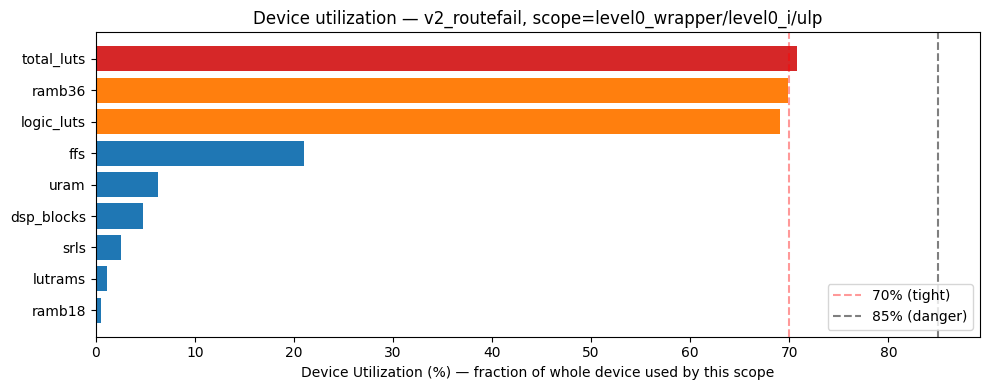


Critical (>=40% of device): ['total_luts', 'ramb36', 'logic_luts']
All active resources iterated in sections 4-11: ['total_luts', 'logic_luts', 'lutrams', 'srls', 'ffs', 'ramb36', 'ramb18', 'uram', 'dsp_blocks']


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728' if p > 70 else '#ff7f0e' if p > 40 else '#1f77b4' for p in summary['util_pct']]
ax.barh(summary['resource'], summary['util_pct'], color=colors)
ax.axvline(70, color='red',   linestyle='--', alpha=0.4, label='70% (tight)')
ax.axvline(85, color='black', linestyle='--', alpha=0.5, label='85% (danger)')
ax.set_xlabel('Device Utilization (%) — fraction of whole device used by this scope')
ax.set_title(f'Device utilization — {tag}, scope={scope_root or "whole chip"}')
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

# Per-resource loops below iterate ACTIVE_RESOURCES (all non-zero resource types).
# `critical` is kept only for quick "tight ones first" summaries.
critical = summary[summary['util_pct'] >= 40]['resource'].tolist()
print(f"\nCritical (>=40% of device): {critical}")
print(f"All active resources iterated in sections 4-11: {ACTIVE_RESOURCES}")


## 4. Bottleneck: 리소스별 Top-N 모듈

크리티컬한 자원 위주로 어떤 모듈이 많이 먹는지 본다. `is_self=False` 인 행만 사용 (계층 집계값).

In [6]:
def top_consumers(df, resource, depth_max=None, n=15):
    sub = df[~df['is_self']].copy()
    if depth_max is not None:
        sub = sub[sub['depth'] <= depth_max]
    top_used = df[(df['depth'] == 0) & (~df['is_self'])].iloc[0][resource]
    budget = DEVICE_BUDGET.get(resource, 0)
    out = sub.nlargest(n, resource)[['depth', 'full_path', 'module', resource]].copy()
    out['pct_of_scope']  = out[resource] / top_used * 100 if top_used else 0
    out['pct_of_device'] = out[resource] / budget * 100 if budget else float('nan')
    return out.reset_index(drop=True)

for r in ACTIVE_RESOURCES:
    print(f"\n=== Top 10 consumers of {r} (depth<=4) ===")
    print(top_consumers(df, r, depth_max=4, n=10).to_string(index=False))



=== Top 10 consumers of total_luts (depth<=4) ===
 depth                                                         full_path                           module  total_luts  pct_of_scope  pct_of_device
     0                                       level0_wrapper/level0_i/ulp                              ulp      922890    100.000000      70.770300
     1                          level0_wrapper/level0_i/ulp/vortex_afu_1               ulp_vortex_afu_1_0      867344     93.981298      66.510846
     2                     level0_wrapper/level0_i/ulp/vortex_afu_1/inst    ulp_vortex_afu_1_0_vortex_afu      867344     93.981298      66.510846
     3            level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap   ulp_vortex_afu_1_0_VX_afu_wrap      867344     93.981298      66.510846
     4 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi    ulp_vortex_afu_1_0_Vortex_axi      867234     93.969379      66.502411
     1                                level0_wrapper/level0_i/ulp/h

 depth                                                        full_path                           module  lutrams  pct_of_scope  pct_of_device
     0                                      level0_wrapper/level0_i/ulp                              ulp     7044    100.000000       1.172125
     1                               level0_wrapper/level0_i/ulp/hmss_0                     ulp_hmss_0_0     6932     98.409994       1.153488
     2                          level0_wrapper/level0_i/ulp/hmss_0/inst             ulp_hmss_0_0_bd_85ad     6932     98.409994       1.153488
     3                  level0_wrapper/level0_i/ulp/hmss_0/inst/path_12  ulp_hmss_0_0_path_12_imp_PXRVTC      772     10.959682       0.128461
     4 level0_wrapper/level0_i/ulp/hmss_0/inst/path_12/interconnect1_12       bd_85ad_interconnect1_12_0      772     10.959682       0.128461
     3                  level0_wrapper/level0_i/ulp/hmss_0/inst/path_13 ulp_hmss_0_0_path_13_imp_14GJKGE      772     10.959682       0.128461

## 5. Leaf-level 누적 (own resource) Top-N

계층 집계값이 아니라 "자기 자신만의" 자원 소비 (`is_self=True`) + 리프 모듈을 합쳐 실제 bottleneck 을 만드는 **최하위 원인** 찾기.

In [7]:
def leaf_consumers(df, resource, n=20):
    # 리프 = 이 인스턴스를 접두사로 갖는 더 깊은 일반(child) 행이 없음
    non_self = df[~df['is_self']].copy()
    paths = non_self['full_path'].tolist()
    path_set = set(paths)
    is_leaf = []
    for p in paths:
        prefix = p + '/'
        has_child = any(q.startswith(prefix) for q in path_set if q != p)
        is_leaf.append(not has_child)
    non_self = non_self.assign(is_leaf=is_leaf)
    leaves = non_self[non_self['is_leaf']]
    return leaves.nlargest(n, resource)[['depth', 'full_path', 'module', resource]].reset_index(drop=True)

for r in ACTIVE_RESOURCES:
    print(f"\n=== Leaf-level top 10 for {r} ===")
    print(leaf_consumers(df, r, n=10).to_string(index=False))



=== Leaf-level top 10 for total_luts ===


 depth                                                                                                                                                                                                                                                             full_path                                                    module  total_luts
    12                                                                                       level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_VX_gemm_unit/u_mxu/u_weight_regs                 ulp_vortex_afu_1_0_VX_gemm_weight_regs_v1       36358
    14     level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/mem_unit/g_lmem_switches[0].lmem_switch/req_dma_buf/g_eb1.pipe_buffer/g_register.g_pipe_regs[0].pipe_register/g_shift_register ulp_vortex_afu_1_0_VX_shift_register__parameterized29

 depth                                                                                                                                                                                                                                                             full_path                                                    module  logic_luts
    12                                                                                       level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_VX_gemm_unit/u_mxu/u_weight_regs                 ulp_vortex_afu_1_0_VX_gemm_weight_regs_v1       36358
    14     level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/mem_unit/g_lmem_switches[0].lmem_switch/req_dma_buf/g_eb1.pipe_buffer/g_register.g_pipe_regs[0].pipe_register/g_shift_register ulp_vortex_afu_1_0_VX_shift_register__parameterized29

 depth                                                                                                                                                                                                                              full_path                                                        module  lutrams
    13   level0_wrapper/level0_i/ulp/hmss_0/inst/path_8/interconnect0_8/inst/s00_nodes/s00_r_node/inst/inst_mi_handler/gen_normal_area.inst_fifo_node_payld/gen_xpm_memory_fifo.inst_fifo/gen_mem_rep[1].inst_xpm_memory/xpm_memory_base_inst  bd_85ad_interconnect0_8_0_xpm_memory_base__parameterized1__2      106
    13 level0_wrapper/level0_i/ulp/hmss_0/inst/path_12/interconnect1_12/inst/s00_nodes/s00_r_node/inst/inst_mi_handler/gen_normal_area.inst_fifo_node_payld/gen_xpm_memory_fifo.inst_fifo/gen_mem_rep[1].inst_xpm_memory/xpm_memory_base_inst bd_85ad_interconnect1_12_0_xpm_memory_base__parameterized1__2      106
    13 level0_wrapper/level0_i/ulp/hmss_0/inst/path_13/interconnect2_13/i

 depth                                                                                                                                                                                                                                    full_path                                                                          module  srls
    13 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_VX_gemm_unit/u_pre_proc_pipe_buffer/g_register.g_pipe_regs[31].pipe_register/g_shift_register                       ulp_vortex_afu_1_0_VX_shift_register__parameterized45_393  1312
     8                                                                                                                          level0_wrapper/level0_i/ulp/hmss_0/inst/path_8/slice0_8/inst/w15.w_multi/triple_slr.fwd.slr_slave/common.srl_fifo_0 bd_85ad_slice0_8_0_axi_register_slice_v2_1_35_axic_reg_srl_fifo__parameterized0   580
     8    

 depth                                                                                                                                                                                                                      full_path                                                                          module  ffs
    12                                                level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_VX_gemm_unit/u_mxu/u_weight_regs                                       ulp_vortex_afu_1_0_VX_gemm_weight_regs_v1 8192
    11                                           level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/u_VX_dma_node/u_job_frontend/u_job_desc_mmio_regs                                        ulp_vortex_afu_1_0_VX_job_desc_mmio_regs 2875
    14 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/af

 depth                                                                                                                                                                             full_path                                           module  ramb36
    12 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_tmem_subsystem/g_bank[0].u_bank/sp_ram ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_344      64
    12 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_tmem_subsystem/g_bank[1].u_bank/sp_ram ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_339      64
    12 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_tmem_subsystem/g_bank[2].u_bank/sp_ram ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_334      64
    12 level0_wr

 depth                                                                                                                                                                                                                                             full_path                                                                        module  ramb18
    15            level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/execute/lsu_unit/g_blocks[0].lsu_slice/mem_scheduler/req_ibuf/data_table/g_async.g_bram.async_ram_patch                         ulp_vortex_afu_1_0_VX_async_ram_patch__parameterized1       1
    13                        level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_VX_gemm_ctrl/u_parent_cmd_queue/g_depth_n.dp_ram/g_async.g_bram.async_ram_patch                         ulp_vortex_afu_1_0_VX_async_ram_patch__parame

 depth                                                                                                                                                                                     full_path                                                                                         module  uram
    11 level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/gemm_node/u_VX_gemm_unit/gen_acc_mem[3].VX_sp_ram_instance                                               ulp_vortex_afu_1_0_VX_sp_ram__parameterized1_354    15
     3                                                                                                                                 level0_wrapper/level0_i/ulp/SLR0/regslice_control_userpf/inst                    ulp_regslice_control_userpf_0_axi_register_slice_v2_1_35_axi_register_slice     0
     5                                                                                                    

 depth                                                                                                                                                                                                     full_path                                 module  dsp_blocks
    11                                  level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/u_VX_dma_node/u_dma_unit_misal/mul_dst_d0     ulp_vortex_afu_1_0_VX_mul_u32_pipe           4
    11                                  level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/u_VX_dma_node/u_dma_unit_misal/mul_dst_d1  ulp_vortex_afu_1_0_VX_mul_u32_pipe_76           4
    11                                  level0_wrapper/level0_i/ulp/vortex_afu_1/inst/afu_wrap/vortex_axi/vortex/g_clusters[0].cluster/g_sockets[0].socket/g_cores[0].core/u_VX_dma_node/u_dma_unit_misal/mul_sr

## 6. 특정 계층 레벨에서 stacked bar

`depth=N` 자식들이 top 에서 어떻게 쪼개지는지 한눈에. 보통 depth 2~3 에서 kernel/서브블록 단위가 보입니다.

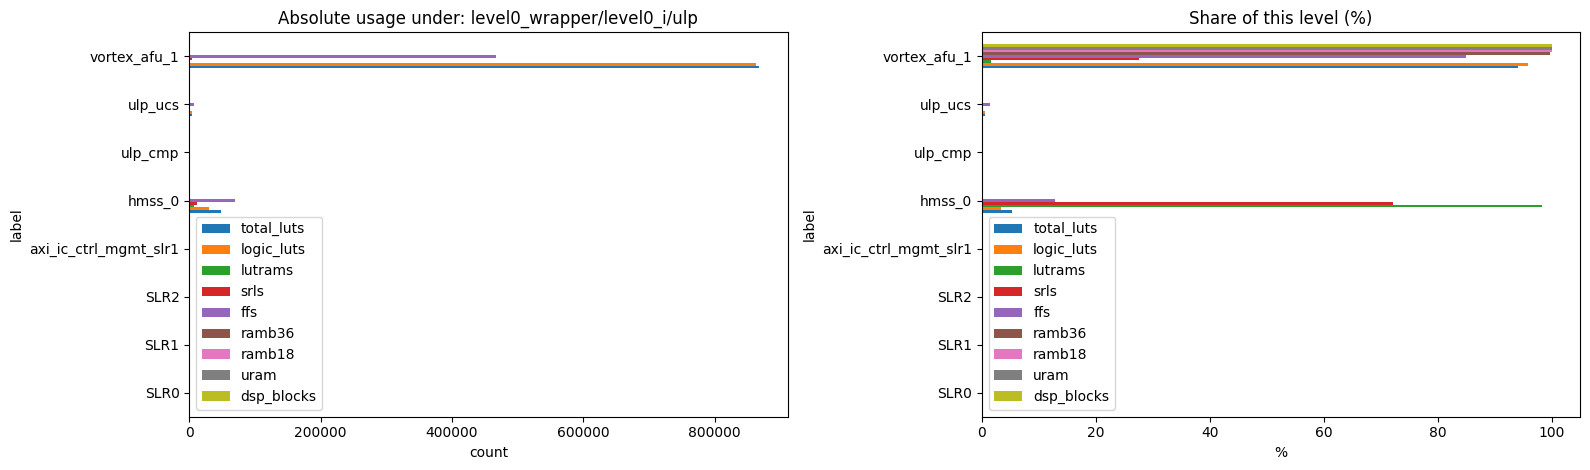

,total_luts,logic_luts,lutrams,srls,ffs,ramb36,ramb18,uram,dsp_blocks
label,,,,,,,,,
SLR0,413,413,0,0,1565,0,0,0,0
SLR1,215,215,0,0,915,0,0,0,0
SLR2,215,215,0,0,915,0,0,0,0
axi_ic_ctrl_mgmt_slr1,111,111,0,0,123,0,0,0,0
hmss_0,48274,30149,6932,11193,70232,4,0,0,0
ulp_cmp,554,554,0,0,670,0,0,0,0
ulp_ucs,4711,4691,0,20,7801,0,0,0,0
vortex_afu_1,867344,862952,112,4280,466499,1405,21,60,428


In [8]:
def children_at(df, parent_path, show_resources=None, topk=None):
    """parent_path 바로 아래 자식들의 리소스 분포를 stacked bar 로.
    parent_path='' 면 scope root 의 직속 자식(depth==1)."""
    resources = show_resources or RES_KEYS
    non_self = df[~df['is_self']].copy()
    if parent_path:
        parent_row = non_self[non_self['full_path'] == parent_path]
        if len(parent_row) == 0:
            raise ValueError(f"parent_path not found: {parent_path}")
        parent_depth = int(parent_row.iloc[0]['depth'])
        prefix = parent_path + '/'
        kids = non_self[
            non_self['full_path'].str.startswith(prefix) &
            (non_self['depth'] == parent_depth + 1)
        ]
    else:
        kids = non_self[non_self['depth'] == 1]

    kids = kids.copy()
    kids['label'] = kids['full_path'].apply(lambda p: p.rsplit('/', 1)[-1])

    if topk:
        pick = kids.nlargest(topk, resources[0])['label'].tolist()
        kids = kids[kids['label'].isin(pick)]

    pivot = kids.set_index('label')[resources]
    normed = pivot.div(pivot.sum(axis=0).replace(0, 1), axis=1) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.35 * len(pivot) + 2))
    pivot.plot.barh(stacked=False, ax=ax1)
    ax1.set_title(f'Absolute usage under: {parent_path or scope_root or "<top>"}')
    ax1.set_xlabel('count')
    normed.plot.barh(stacked=False, ax=ax2)
    ax2.set_title('Share of this level (%)')
    ax2.set_xlabel('%')
    plt.tight_layout(); plt.show()
    return pivot

# 직속 자식 of scope root
children_at(df, parent_path='', show_resources=ACTIVE_RESOURCES, topk=12)


특정 서브트리 drill-down 예시 (위 결과에서 제일 큰 자식 경로를 넣어 반복):


>>> drill-down for total_luts: level0_wrapper/level0_i/ulp/vortex_afu_1


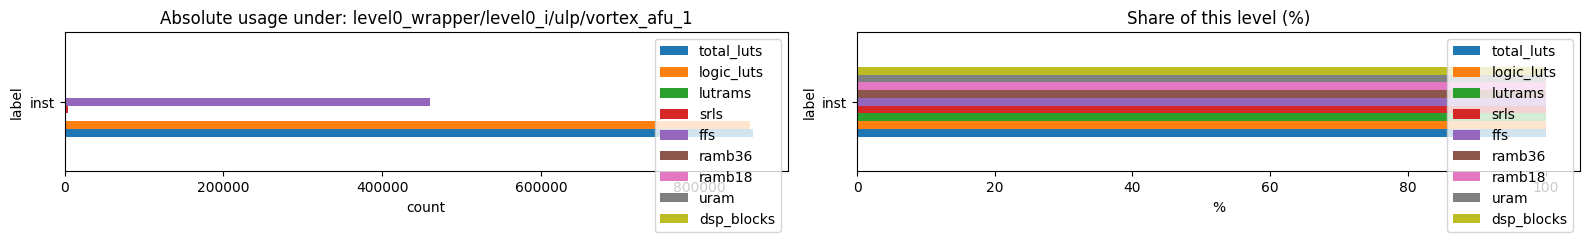


>>> drill-down for logic_luts: level0_wrapper/level0_i/ulp/vortex_afu_1


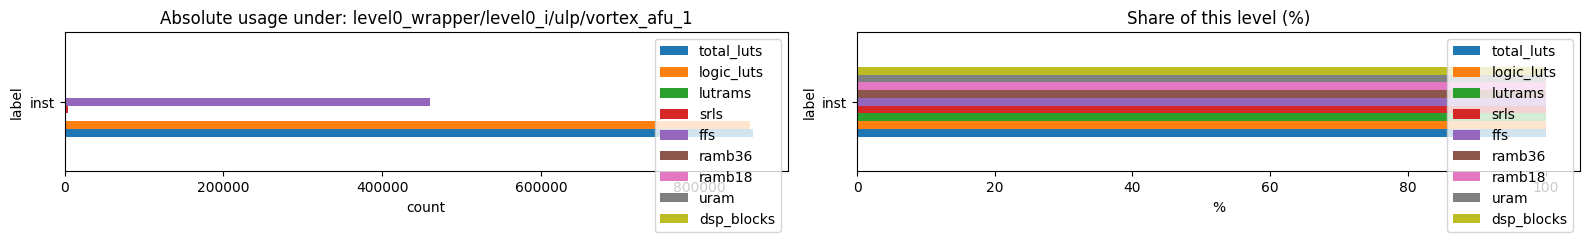


>>> drill-down for lutrams: level0_wrapper/level0_i/ulp/hmss_0


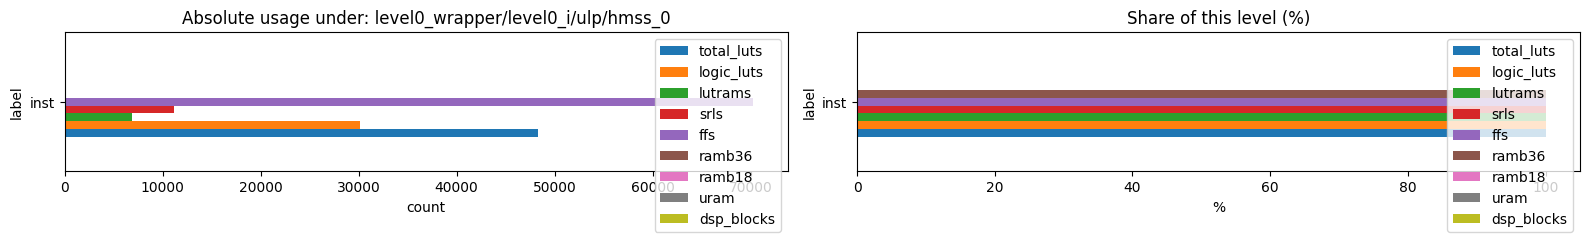


>>> drill-down for srls: level0_wrapper/level0_i/ulp/hmss_0


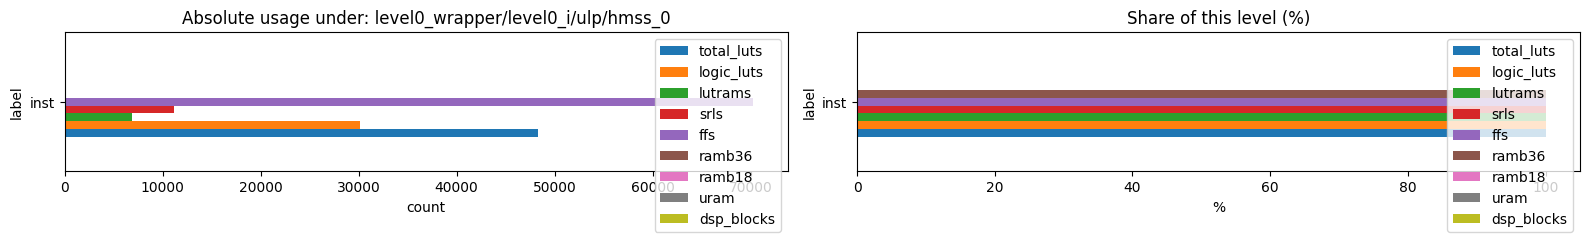


>>> drill-down for ffs: level0_wrapper/level0_i/ulp/vortex_afu_1


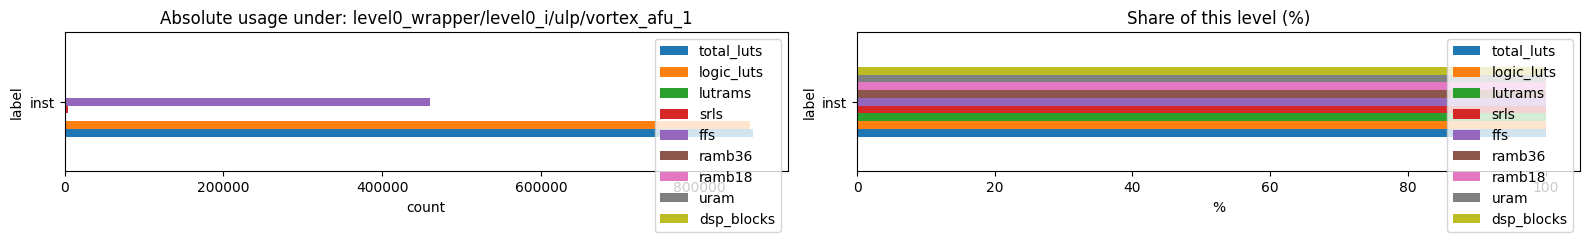


>>> drill-down for ramb36: level0_wrapper/level0_i/ulp/vortex_afu_1


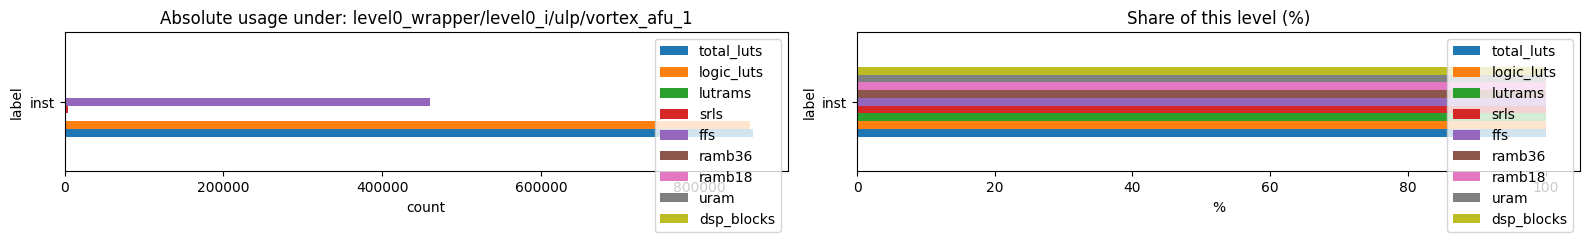


>>> drill-down for ramb18: level0_wrapper/level0_i/ulp/vortex_afu_1


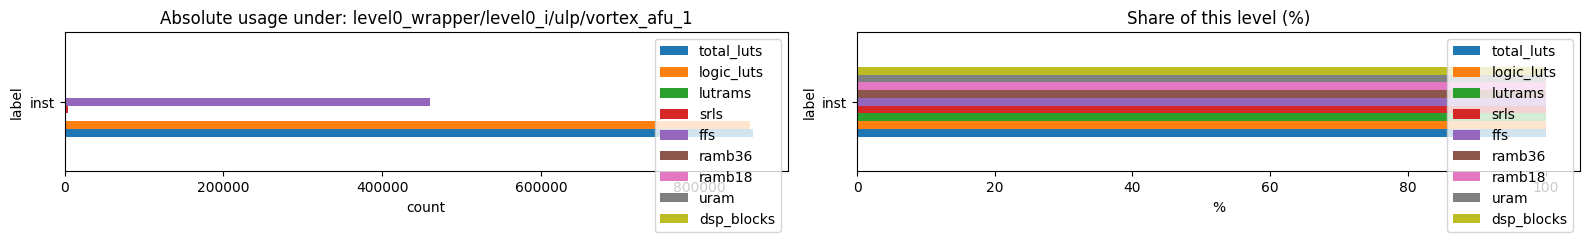


>>> drill-down for uram: level0_wrapper/level0_i/ulp/vortex_afu_1


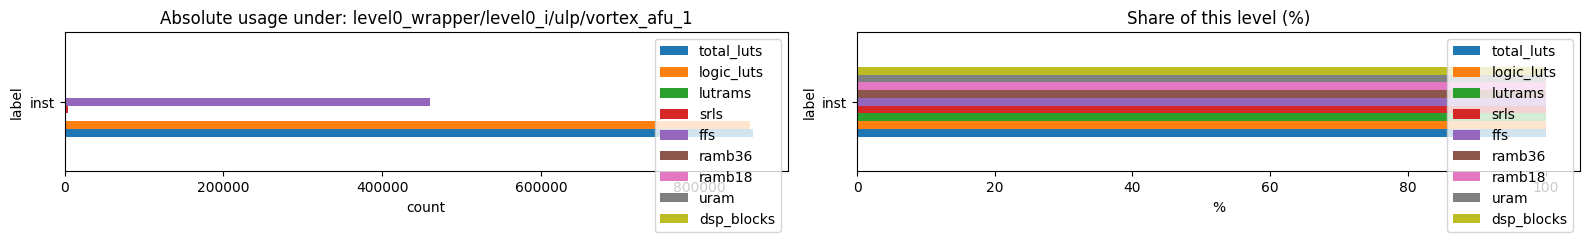


>>> drill-down for dsp_blocks: level0_wrapper/level0_i/ulp/vortex_afu_1


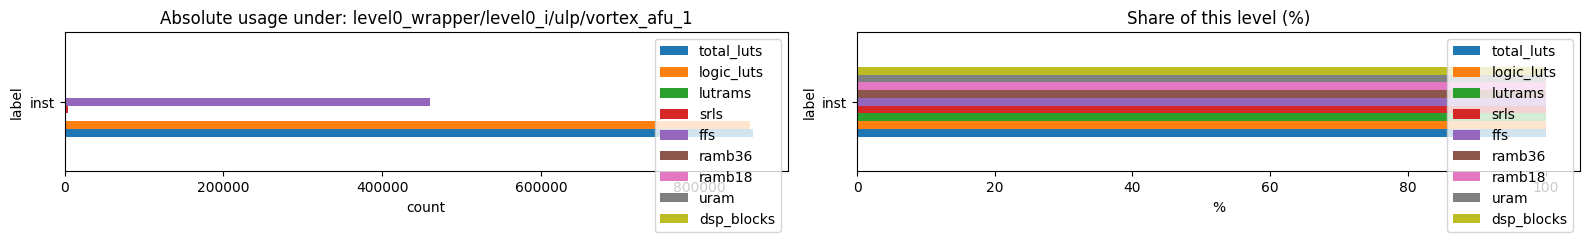

In [9]:
# 각 resource 별로, scope root 직속 자식 중 가장 많이 먹는 path 로 한 단계 더 drill-down
for r in ACTIVE_RESOURCES:
    kids_l1 = df[~df['is_self'] & (df['depth'] == 1)]
    if len(kids_l1) == 0 or kids_l1[r].max() == 0:
        continue
    biggest = kids_l1.nlargest(1, r)['full_path'].iloc[0]
    print(f"\n>>> drill-down for {r}: {biggest}")
    children_at(df, parent_path=biggest, show_resources=ACTIVE_RESOURCES, topk=12);


## 7. Pareto 분석

"80% 의 리소스를 몇 개 모듈이 먹는가" — 너무 plat 하다면 소수 모듈 최적화로는 개선 폭이 작다는 신호.

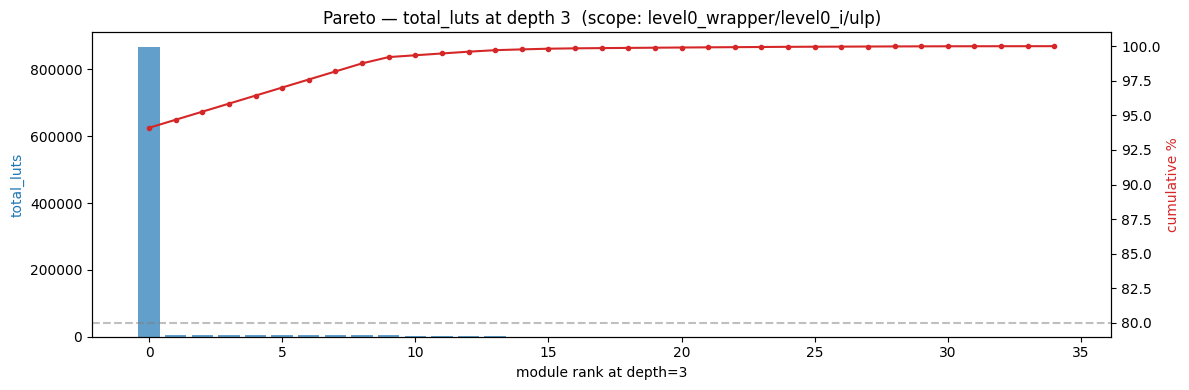

=> 1 modules account for first 80% of total_luts


,full_path,module,total_luts,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,867344,94.09988


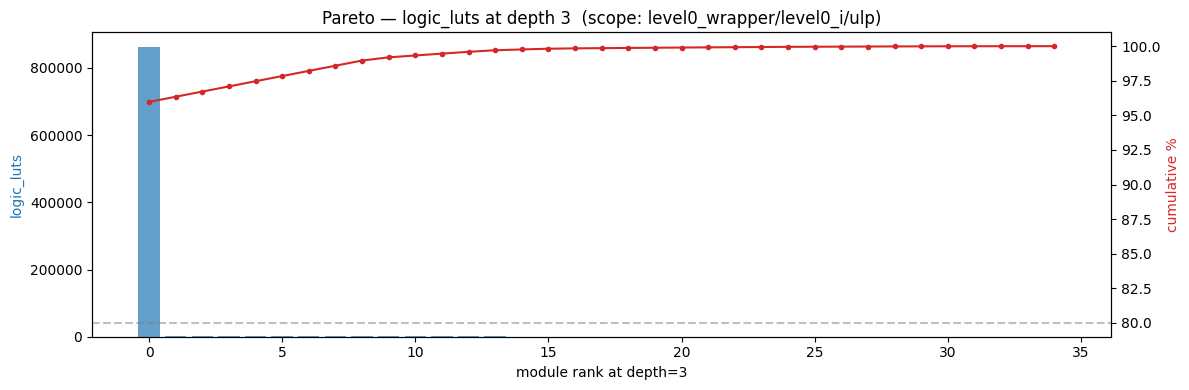

=> 1 modules account for first 80% of logic_luts


,full_path,module,logic_luts,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,862952,95.969715


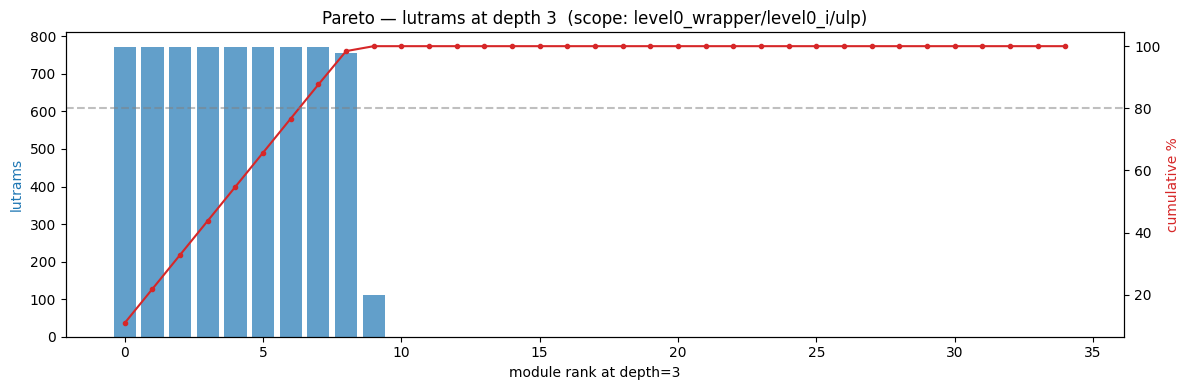

=> 8 modules account for first 80% of lutrams


,full_path,module,lutrams,cum_pct
0,level0_wrapper/level0_i/ulp/hmss_0/inst/path_13,ulp_hmss_0_0_path_13_imp_14GJKGE,772,10.959682
1,level0_wrapper/level0_i/ulp/hmss_0/inst/path_12,ulp_hmss_0_0_path_12_imp_PXRVTC,772,21.919364
2,level0_wrapper/level0_i/ulp/hmss_0/inst/path_14,ulp_hmss_0_0_path_14_imp_1711ZKN,772,32.879046
3,level0_wrapper/level0_i/ulp/hmss_0/inst/path_18,ulp_hmss_0_0_path_18_imp_1KT0JYW,772,43.838728
4,level0_wrapper/level0_i/ulp/hmss_0/inst/path_17,ulp_hmss_0_0_path_17_imp_5ZTZN8,772,54.798410
5,level0_wrapper/level0_i/ulp/hmss_0/inst/path_16,ulp_hmss_0_0_path_16_imp_1O9HICQ,772,65.758092
6,level0_wrapper/level0_i/ulp/hmss_0/inst/path_19,ulp_hmss_0_0_path_19_imp_OLFQ,772,76.717774
7,level0_wrapper/level0_i/ulp/hmss_0/inst/path_15,ulp_hmss_0_0_path_15_imp_OCGE6H,772,87.677456


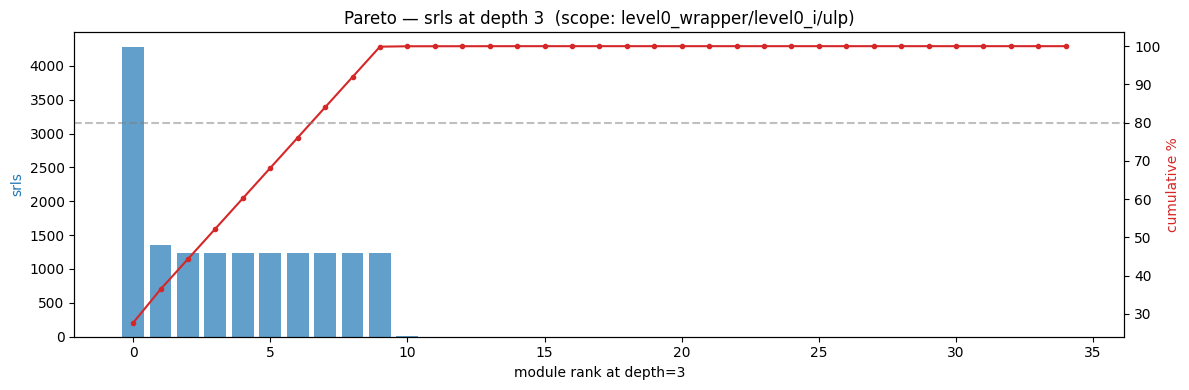

=> 8 modules account for first 80% of srls


,full_path,module,srls,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,4280,27.628946
1,level0_wrapper/level0_i/ulp/hmss_0/inst/path_8,ulp_hmss_0_0_path_8_imp_8YHLSO,1359,36.401782
2,level0_wrapper/level0_i/ulp/hmss_0/inst/path_14,ulp_hmss_0_0_path_14_imp_1711ZKN,1229,44.335421
3,level0_wrapper/level0_i/ulp/hmss_0/inst/path_18,ulp_hmss_0_0_path_18_imp_1KT0JYW,1229,52.269059
4,level0_wrapper/level0_i/ulp/hmss_0/inst/path_19,ulp_hmss_0_0_path_19_imp_OLFQ,1229,60.202698
5,level0_wrapper/level0_i/ulp/hmss_0/inst/path_15,ulp_hmss_0_0_path_15_imp_OCGE6H,1229,68.136337
6,level0_wrapper/level0_i/ulp/hmss_0/inst/path_12,ulp_hmss_0_0_path_12_imp_PXRVTC,1229,76.069976
7,level0_wrapper/level0_i/ulp/hmss_0/inst/path_16,ulp_hmss_0_0_path_16_imp_1O9HICQ,1229,84.003615


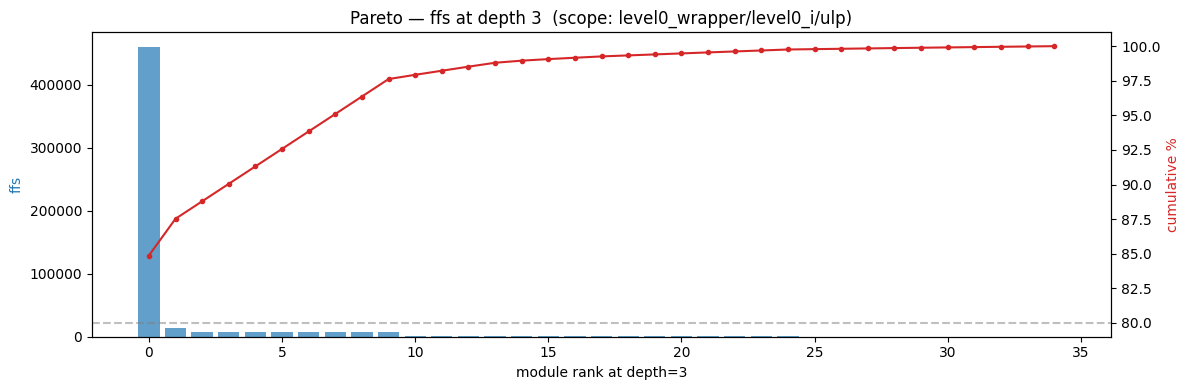

=> 1 modules account for first 80% of ffs


,full_path,module,ffs,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,460547,84.869521


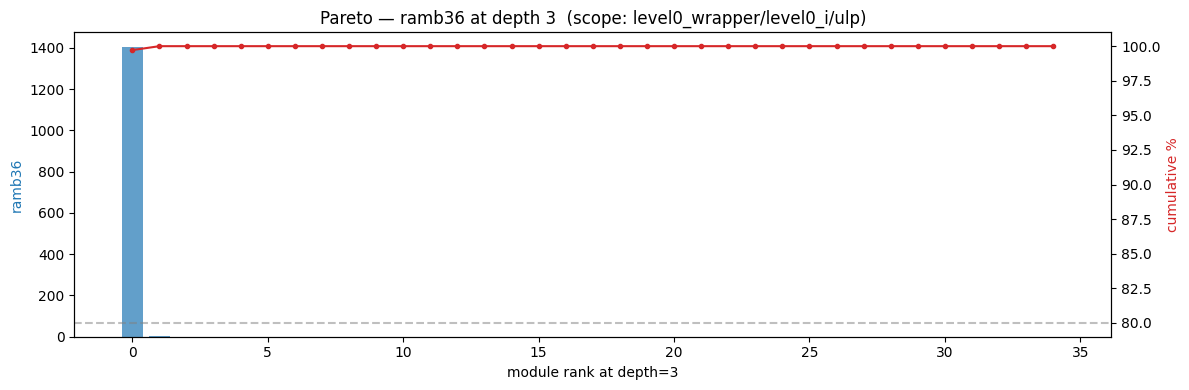

=> 1 modules account for first 80% of ramb36


,full_path,module,ramb36,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,1405,99.716111


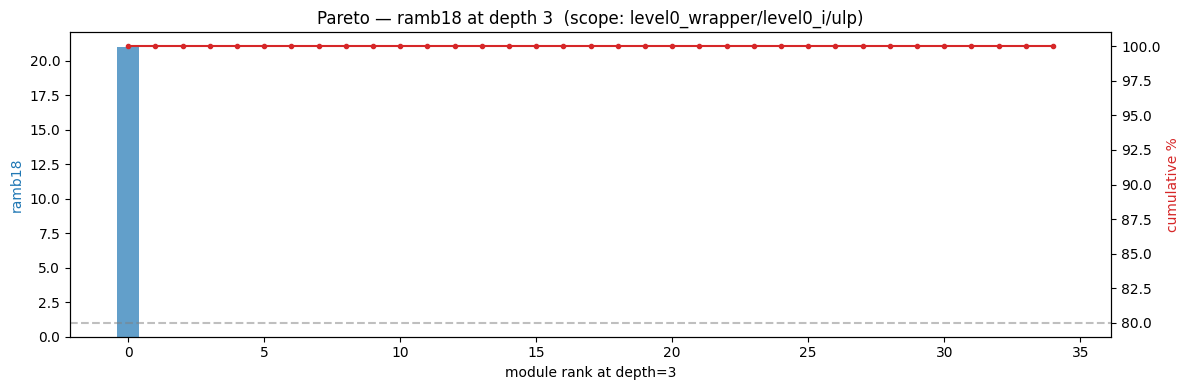

=> 1 modules account for first 80% of ramb18


,full_path,module,ramb18,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,21,100.0


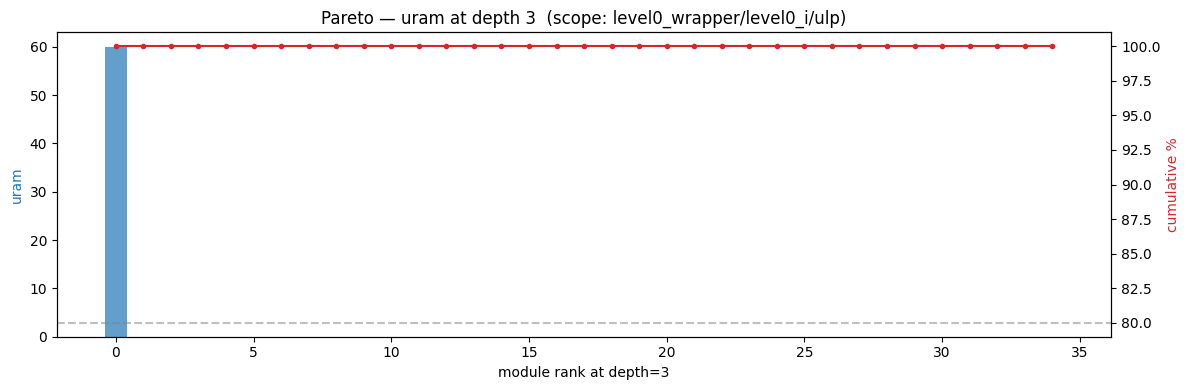

=> 1 modules account for first 80% of uram


,full_path,module,uram,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,60,100.0


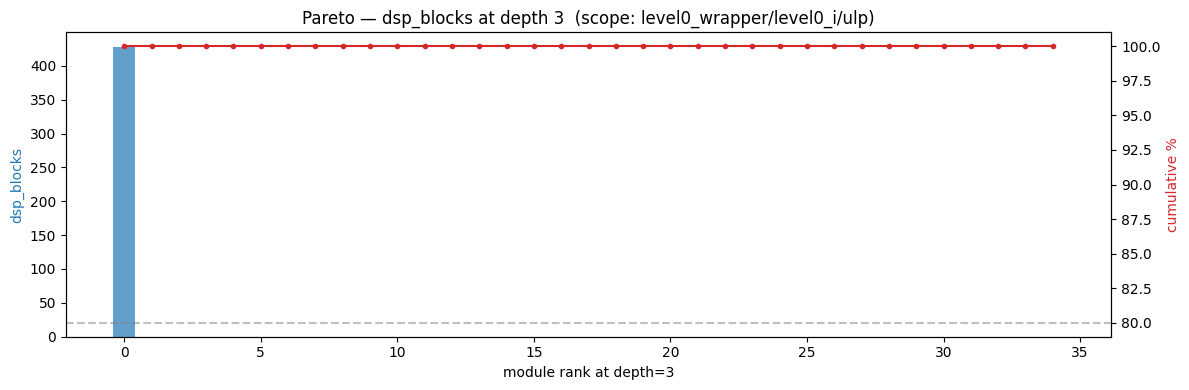

=> 1 modules account for first 80% of dsp_blocks


,full_path,module,dsp_blocks,cum_pct
0,level0_wrapper/level0_i/ulp/vortex_afu_1/inst/...,ulp_vortex_afu_1_0_VX_afu_wrap,428,100.0


In [10]:
def pareto(df, resource, depth=3):
    sub = df[~df['is_self'] & (df['depth'] == depth)].sort_values(resource, ascending=False).reset_index(drop=True)
    if len(sub) == 0 or sub[resource].sum() == 0:
        print(f"(no data at depth={depth} for {resource})")
        return pd.DataFrame()
    total = sub[resource].sum()
    sub['cum_pct'] = sub[resource].cumsum() / total * 100

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(sub)), sub[resource], color='#1f77b4', alpha=0.7)
    ax.set_ylabel(resource, color='#1f77b4')
    ax.set_xlabel(f'module rank at depth={depth}')
    ax2 = ax.twinx()
    ax2.plot(range(len(sub)), sub['cum_pct'], color='#d62728', marker='.')
    ax2.axhline(80, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel('cumulative %', color='#d62728')
    ax.set_title(f'Pareto — {resource} at depth {depth}  (scope: {scope_root or "chip"})')
    plt.tight_layout(); plt.show()

    n_80 = int((sub['cum_pct'] <= 80).sum()) + 1
    print(f"=> {n_80} modules account for first 80% of {resource}")
    return sub.head(n_80)[['full_path', 'module', resource, 'cum_pct']]

for r in ACTIVE_RESOURCES:
    display(pareto(df, r, depth=3))


## 8. 여러 빌드 비교 (선택)

`REPORTS` 에 여러 tag 를 넣으면 아래 셀이 같은 자원을 빌드별로 비교합니다.

,total_luts,logic_luts,lutrams,srls,ffs,ramb36,ramb18,uram,dsp_blocks
build,,,,,,,,,
v1,1319426,1027512,274194,17720,689462,1602,27,60,432
v2_routefail,1044507,1014737,12050,17720,685316,1602,27,60,432


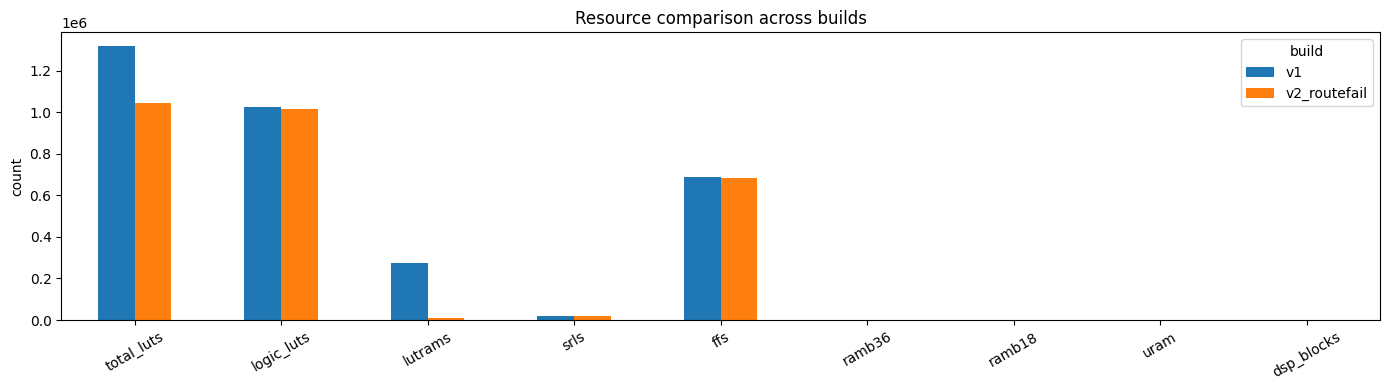

In [11]:
if len(dfs) > 1:
    rows = []
    for t, d in dfs.items():
        top = d[(d['depth'] == 0) & (~d['is_self'])].iloc[0]
        rec = {'build': t}
        for k in RES_KEYS:
            rec[k] = int(top[k])
        rows.append(rec)
    cmp = pd.DataFrame(rows).set_index('build')
    display(cmp)
    cmp.T.plot.bar(figsize=(14, 4)); plt.title('Resource comparison across builds')
    plt.ylabel('count'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()
else:
    print('Add more entries to REPORTS for comparison.')

## 9. Module-type 집계 (RTL 타입별 own-resource)

인스턴스 path 가 아니라 **RTL 모듈 타입**별로 own-resource (`is_self=True`) 를 합산. 자식을 포함하지 않기 때문에 double-count 없이 깔끔하게 "어떤 .sv 파일 하나를 고치면 가장 이득인가?" 에 답합니다.

- `instances`: 해당 모듈 타입이 얼마나 많이 instantiated 되었는가
- `own_<res>`: 그 타입 인스턴스 **자신만의** 리소스 합 (자식 제외)
- `per_inst`: 인스턴스 1개당 평균 own 리소스 → **모듈 최적화 한 번의 효과 크기**
- 합계가 design total 과 일치해야 정상 (self-row 는 트리 전체를 분해함)

In [12]:
def module_type_breakdown(df, resource=None):
    '''Aggregate own-resource (is_self=True) by RTL module type.
    Self-rows partition the total without double-counting.
    '''
    self_df = df[df['is_self']].copy()
    non_self = df[~df['is_self']][['full_path', 'module']].rename(columns={'module': 'mod'})
    merged = self_df.merge(non_self, on='full_path', how='left')
    merged['mod'] = merged['mod'].fillna('(unknown)')

    agg_kwargs = {'instances': ('full_path', 'count')}
    for k in RES_KEYS:
        agg_kwargs[f'own_{k}'] = (k, 'sum')

    g = merged.groupby('mod').agg(**agg_kwargs).reset_index().rename(columns={'mod': 'module'})

    if resource is not None:
        col = f'own_{resource}'
        g['per_inst'] = (g[col] / g['instances']).round(1)
        top_used = df[(df['depth'] == 0) & (~df['is_self'])].iloc[0][resource]
        g['pct_of_scope'] = (g[col] / top_used * 100).round(2) if top_used else 0
        return g.sort_values(col, ascending=False).reset_index(drop=True)
    return g

# Per-resource table: 어떤 모듈 타입(.sv) 최적화가 가장 이득인지 resource 별로 따로
for r in ACTIVE_RESOURCES:
    mt = module_type_breakdown(df, resource=r)
    total_used = df[(df['depth'] == 0) & (~df['is_self'])].iloc[0][r]
    own_sum = mt[f'own_{r}'].sum()
    match = '✓' if int(own_sum) == int(total_used) else '✗'
    print(f"\n=== Module-type own {r}  (scope total={int(total_used):,}, own-sum={int(own_sum):,} {match}) ===")
    cols_show = ['module', 'instances', f'own_{r}', 'per_inst', 'pct_of_scope']
    print(mt[cols_show].head(15).to_string(index=False))



=== Module-type own total_luts  (scope total=922,890, own-sum=585,806 ✗) ===
                                                  module  instances  own_total_luts  per_inst  pct_of_scope
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_275          1           43806   43806.0          4.75
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_276          1           43786   43786.0          4.74
    ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0          1           43784   43784.0          4.74
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_274          1           43784   43784.0          4.74
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_278          1           43784   43784.0          4.74
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_277          1           43781   43781.0          4.74
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_279          1           43781   43781.0          4.74
ulp_vortex_afu_1_0_VX_dma_unit_misal__parameterized0_280  


=== Module-type own ramb18  (scope total=21, own-sum=0 ✗) ===
                                                                       module  instances  own_ramb18  per_inst  pct_of_scope
                                   ulp_vortex_afu_1_0_flt_fma_add_logic_18736          1           0       0.0           0.0
                           bd_097b_build_info_0_shell_utils_build_info_v1_0_0          1           0       0.0           0.0
                                        bd_097b_build_info_0_slave_attachment          1           0       0.0           0.0
                bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake          1           0       0.0           0.0
bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake__parameterized0          1           0       0.0           0.0
bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake__parameterized2          1           0       0.0           0.0
     bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_hands

/tmp/ipykernel_2547238/3974791219.py:13: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(); plt.show()


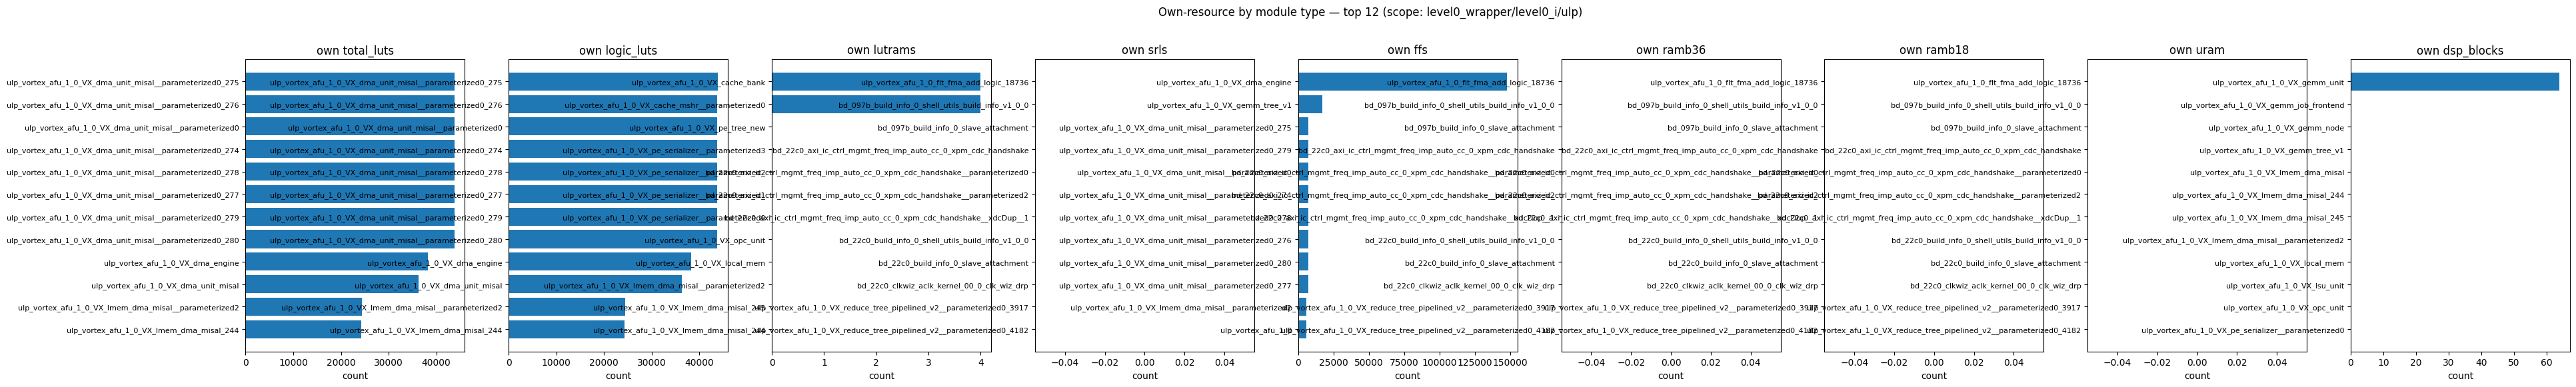

In [13]:
# 한 figure 에 resource 마다 subplot 하나씩 → top-N 모듈 타입
top_n = 12
n_res = len(ACTIVE_RESOURCES)
fig, axes = plt.subplots(1, n_res, figsize=(5 * n_res, max(4, 0.35 * top_n + 1.5)), squeeze=False)
for ax, r in zip(axes[0], ACTIVE_RESOURCES):
    mt_r = module_type_breakdown(df, resource=r).head(top_n)
    ax.barh(mt_r['module'], mt_r[f'own_{r}'], color='#1f77b4')
    ax.invert_yaxis()
    ax.set_title(f'own {r}')
    ax.set_xlabel('count')
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle(f'Own-resource by module type — top {top_n} (scope: {scope_root or "chip"})', y=1.02)
plt.tight_layout(); plt.show()


## 10. Bottleneck chain — critical resource 를 따라 drill-down

Root 에서 시작해 매 depth 마다 critical resource 를 가장 많이 먹는 child 로 내려가며 leaf 까지 추적합니다. "이 resource 가 정확히 어떤 계층 path 에서 쌓이고 있는가"를 한 번에 보여줍니다.

- `pct_of_parent`: 직속 부모 대비 몇 % 를 이 자식이 가져가는가 (100% 에 가까우면 단일 경로 dominant, 낮으면 여러 갈래로 분산)
- 체인 끝 = 이 depth-선형 관점에서 bottleneck 의 뿌리

In [14]:
def bottleneck_chain(df, resource):
    '''Follow the largest child of `resource` from scope root to leaf.'''
    non_self = df[~df['is_self']]
    root = non_self[non_self['depth'] == 0].iloc[0]
    chain = [{
        'depth': 0,
        'full_path': root['full_path'],
        'module': root['module'],
        resource: int(root[resource]),
        'pct_of_parent': 100.0,
    }]
    cur_path = root['full_path']
    cur_val = root[resource]
    while cur_val > 0:
        prefix = cur_path + '/' if cur_path else ''
        kids = non_self[
            non_self['full_path'].str.startswith(prefix) &
            (non_self['depth'] == chain[-1]['depth'] + 1)
        ]
        if len(kids) == 0:
            break
        top = kids.nlargest(1, resource).iloc[0]
        if top[resource] == 0:
            break
        chain.append({
            'depth': chain[-1]['depth'] + 1,
            'full_path': top['full_path'],
            'module': top['module'],
            resource: int(top[resource]),
            'pct_of_parent': round(top[resource] / cur_val * 100, 1) if cur_val else 0,
        })
        cur_path = top['full_path']
        cur_val = top[resource]
    return pd.DataFrame(chain)

for r in ACTIVE_RESOURCES:
    ch = bottleneck_chain(df, r)
    if len(ch) <= 1 or ch[r].iloc[0] == 0:
        continue
    print(f"\n=== Bottleneck chain for {r} ===")
    ch_disp = ch.copy()
    ch_disp['tail'] = ch_disp['full_path'].apply(lambda p: p.rsplit('/', 1)[-1])
    print(ch_disp[['depth', 'tail', 'module', r, 'pct_of_parent']].to_string(index=False))



=== Bottleneck chain for total_luts ===
 depth                    tail                                                   module  total_luts  pct_of_parent
     0                     ulp                                                      ulp      922890          100.0
     1            vortex_afu_1                                       ulp_vortex_afu_1_0      867344           94.0
     2                    inst                            ulp_vortex_afu_1_0_vortex_afu      867344          100.0
     3                afu_wrap                           ulp_vortex_afu_1_0_VX_afu_wrap      867344          100.0
     4              vortex_axi                            ulp_vortex_afu_1_0_Vortex_axi      867234          100.0
     5                  vortex                                ulp_vortex_afu_1_0_Vortex      860648           99.2
     6   g_clusters[0].cluster                            ulp_vortex_afu_1_0_VX_cluster      860604          100.0
     7     g_sockets[0].socket         


=== Bottleneck chain for dsp_blocks ===
 depth                             tail                                                            module  dsp_blocks  pct_of_parent
     0                              ulp                                                               ulp         428          100.0
     1                     vortex_afu_1                                                ulp_vortex_afu_1_0         428          100.0
     2                             inst                                     ulp_vortex_afu_1_0_vortex_afu         428          100.0
     3                         afu_wrap                                    ulp_vortex_afu_1_0_VX_afu_wrap         428          100.0
     4                       vortex_axi                                     ulp_vortex_afu_1_0_Vortex_axi         428          100.0
     5                           vortex                                         ulp_vortex_afu_1_0_Vortex         428          100.0
     6            g_clusters

## 11. Optimization leverage — 모듈 최적화 vs. 인스턴스 수 감축

Leaf 모듈 타입마다 `(instances, per_inst own-cost, total)` 를 보여줘서 **어떤 전략이 더 효과적인지** 판단을 돕습니다:

- **per_inst 가 크고 instances 가 적다** → 그 모듈 RTL 최적화가 답 (소수 인스턴스라 count 줄이기 어려움)
- **per_inst 가 작지만 instances 가 많다** → count 자체를 줄이는 설계 변경이 답 (한 모듈 최적화는 amortize 작음)
- **둘 다 큰 경우** → 최상위 타겟. 어느 쪽이든 큰 이득.


=== Leaf-module leverage for total_luts ===
                                                   module  instances  total  per_inst  pct_of_scope
                ulp_vortex_afu_1_0_VX_gemm_weight_regs_v1          1  36358   36358.0          3.94
ulp_vortex_afu_1_0_VX_shift_register__parameterized29_200          1  28535   28535.0          3.09
  ulp_vortex_afu_1_0_VX_stream_buffer__parameterized5_236          1  14354   14354.0          1.56
    ulp_vortex_afu_1_0_VX_shift_register__parameterized50          1   8096    8096.0          0.88
     ulp_vortex_afu_1_0_VX_shift_register__parameterized4          1   6404    6404.0          0.69
    ulp_vortex_afu_1_0_VX_shift_register__parameterized40          1   6328    6328.0          0.69
         ulp_vortex_afu_1_0_VX_sp_ram__parameterized1_354          1   5926    5926.0          0.64
     ulp_vortex_afu_1_0_VX_stream_buffer__parameterized27          1   4635    4635.0          0.50
ulp_vortex_afu_1_0_VX_shift_register__parameterized29_1


=== Leaf-module leverage for logic_luts ===
                                                   module  instances  total  per_inst  pct_of_scope
                ulp_vortex_afu_1_0_VX_gemm_weight_regs_v1          1  36358   36358.0          4.04
ulp_vortex_afu_1_0_VX_shift_register__parameterized29_200          1  28535   28535.0          3.17
  ulp_vortex_afu_1_0_VX_stream_buffer__parameterized5_236          1  14354   14354.0          1.59
    ulp_vortex_afu_1_0_VX_shift_register__parameterized50          1   8096    8096.0          0.90
     ulp_vortex_afu_1_0_VX_shift_register__parameterized4          1   6404    6404.0          0.71
    ulp_vortex_afu_1_0_VX_shift_register__parameterized40          1   6328    6328.0          0.70
         ulp_vortex_afu_1_0_VX_sp_ram__parameterized1_354          1   5926    5926.0          0.66
     ulp_vortex_afu_1_0_VX_stream_buffer__parameterized27          1   4635    4635.0          0.51
ulp_vortex_afu_1_0_VX_shift_register__parameterized29_1


=== Leaf-module leverage for lutrams ===
                                                       module  instances  total  per_inst  pct_of_scope
 bd_85ad_interconnect0_8_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect1_12_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect2_13_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect3_14_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect4_15_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect5_16_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect6_17_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect7_18_0_xpm_memory_base__parameterized1__2          1    106     106.0          1.50
bd_85ad_interconnect8_


=== Leaf-module leverage for srls ===
                                                                         module  instances  total  per_inst  pct_of_scope
                      ulp_vortex_afu_1_0_VX_shift_register__parameterized45_393          1   1312    1312.0          8.46
bd_85ad_slice0_8_0_axi_register_slice_v2_1_35_axic_reg_srl_fifo__parameterized0          1    580     580.0          3.74
bd_85ad_slice0_8_0_axi_register_slice_v2_1_35_axic_reg_srl_fifo__parameterized2          1    520     520.0          3.35
                bd_85ad_slice0_8_0_axi_register_slice_v2_1_35_axic_reg_srl_fifo          1    114     114.0          0.74
              bd_85ad_slice0_8_0_axi_register_slice_v2_1_35_axic_reg_srl_fifo_4          1    114     114.0          0.74
                             ulp_vortex_afu_1_0_VX_pipe_buffer__parameterized32          1     41      41.0          0.26
                             ulp_vortex_afu_1_0_VX_pipe_buffer__parameterized33          1     41      41.0


=== Leaf-module leverage for ffs ===
                                                                         module  instances  total  per_inst  pct_of_scope
                                      ulp_vortex_afu_1_0_VX_gemm_weight_regs_v1          1   8192    8192.0          1.49
                                       ulp_vortex_afu_1_0_VX_job_desc_mmio_regs          1   2875    2875.0          0.52
                            ulp_vortex_afu_1_0_VX_stream_buffer__parameterized4          1   2873    2873.0          0.52
                        ulp_vortex_afu_1_0_VX_stream_buffer__parameterized5_236          1   2419    2419.0          0.44
                                               ulp_vortex_afu_1_0_VX_serial_mul          1   2088    2088.0          0.38
                                                  ulp_vortex_afu_1_0_VX_fifo_v2          1   2063    2063.0          0.38
                      ulp_vortex_afu_1_0_VX_stream_buffer__parameterized5_16759          1   1764    1764.0 


=== Leaf-module leverage for ramb36 ===
                                                module  instances  total  per_inst  pct_of_scope
                       ulp_vortex_afu_1_0_VX_sp_ram_90          1     64      64.0          4.54
                       ulp_vortex_afu_1_0_VX_sp_ram_98          1     64      64.0          4.54
          ulp_vortex_afu_1_0_VX_sp_ram__parameterized0          1     64      64.0          4.54
      ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_314          1     64      64.0          4.54
      ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_319          1     64      64.0          4.54
      ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_324          1     64      64.0          4.54
      ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_329          1     64      64.0          4.54
      ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_334          1     64      64.0          4.54
      ulp_vortex_afu_1_0_VX_sp_ram__parameterized0_339          1     64      64.0    


=== Leaf-module leverage for ramb18 ===
                                                                                 module  instances  total  per_inst  pct_of_scope
                                  ulp_vortex_afu_1_0_VX_async_ram_patch__parameterized1          1      1       1.0          4.76
                                 ulp_vortex_afu_1_0_VX_async_ram_patch__parameterized10          1      1       1.0          4.76
                                  ulp_vortex_afu_1_0_VX_async_ram_patch__parameterized3          1      1       1.0          4.76
                                  ulp_vortex_afu_1_0_VX_async_ram_patch__parameterized4          1      1       1.0          4.76
                            ulp_vortex_afu_1_0_VX_async_ram_patch__parameterized4_16745          1      1       1.0          4.76
                                        ulp_vortex_afu_1_0_VX_sp_ram__parameterized3_71          1      1       1.0          4.76
                                                 


=== Leaf-module leverage for uram ===
                                                                                 module  instances  total  per_inst  pct_of_scope
                                       ulp_vortex_afu_1_0_VX_sp_ram__parameterized1_354          1     15      15.0          25.0
                                                  bd_097b_build_info_0_slave_attachment          1      0       0.0           0.0
                          bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake          1      0       0.0           0.0
          bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake__parameterized0          1      0       0.0           0.0
          bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake__parameterized2          1      0       0.0           0.0
               bd_22c0_axi_ic_ctrl_mgmt_freq_imp_auto_cc_0_xpm_cdc_handshake__xdcDup__1          1      0       0.0           0.0
        bd_22c0_axi_ic_ctrl_mgmt_freq_imp_xbar_0_ax


=== Leaf-module leverage for dsp_blocks ===
                                module  instances  total  per_inst  pct_of_scope
    ulp_vortex_afu_1_0_VX_mul_u32_pipe          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_260          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_261          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_264          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_265          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_268          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_269          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_272          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_273          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_281          1      4       4.0          0.93
ulp_vortex_afu_1_0_VX_mul_u32_pipe_283          1      4       4

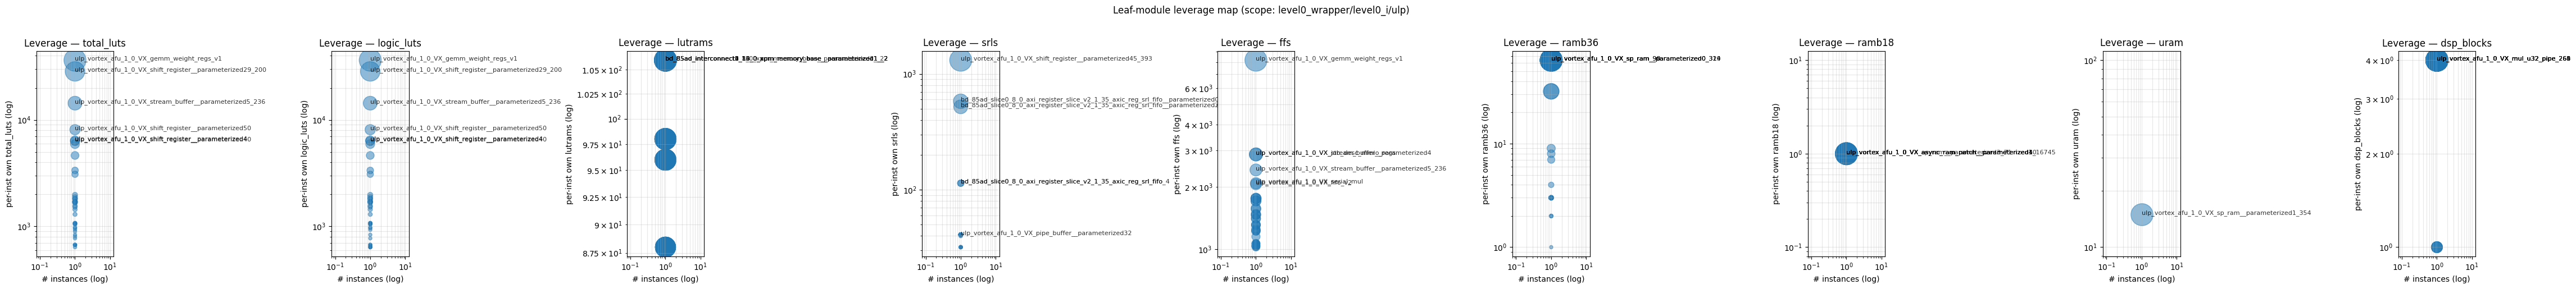

In [15]:
def leaf_leverage(df, resource, n=20):
    '''For leaf instances (no deeper children in non-self rows), aggregate by module type.'''
    non_self = df[~df['is_self']].copy()
    paths = non_self['full_path'].tolist()
    path_set = set(paths)
    is_leaf = []
    for p in paths:
        prefix = p + '/'
        has_child = any(q != p and q.startswith(prefix) for q in path_set)
        is_leaf.append(not has_child)
    non_self = non_self.assign(is_leaf=is_leaf)
    leaves = non_self[non_self['is_leaf'] & (non_self['module'] != '')]

    g = leaves.groupby('module').agg(
        instances=('full_path', 'count'),
        total=(resource, 'sum'),
        per_inst=(resource, 'mean'),
    ).reset_index()
    g['per_inst'] = g['per_inst'].round(1)
    top_used = df[(df['depth'] == 0) & (~df['is_self'])].iloc[0][resource]
    g['pct_of_scope'] = (g['total'] / top_used * 100).round(2) if top_used else 0
    return g.nlargest(n, 'total').reset_index(drop=True)

for r in ACTIVE_RESOURCES:
    lv = leaf_leverage(df, r, n=15)
    if lv.empty or lv['total'].max() == 0:
        continue
    print(f"\n=== Leaf-module leverage for {r} ===")
    print(lv.to_string(index=False))

# Leverage map: per_inst vs instances, bubble=total.  한 figure 에 resource 하나씩.
n_res = len(ACTIVE_RESOURCES)
fig, axes = plt.subplots(1, n_res, figsize=(5 * n_res, 5), squeeze=False)
for ax, r in zip(axes[0], ACTIVE_RESOURCES):
    lv = leaf_leverage(df, r, n=40)
    lv = lv[lv['total'] > 0]
    if lv.empty:
        ax.set_title(f'{r}: no data'); continue
    s = np.clip(lv['total'] / lv['total'].max() * 800, 20, 800)
    ax.scatter(lv['instances'], lv['per_inst'], s=s, alpha=0.5)
    for _, row in lv.head(6).iterrows():
        ax.annotate(row['module'], (row['instances'], row['per_inst']), fontsize=8, alpha=0.8)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('# instances (log)')
    ax.set_ylabel(f'per-inst own {r} (log)')
    ax.set_title(f'Leverage — {r}')
    ax.grid(True, which='both', alpha=0.3)
fig.suptitle(f'Leaf-module leverage map (scope: {scope_root or "chip"})', y=1.02)
plt.tight_layout(); plt.show()
